# ClinVar Variant Analysis

This notebook explores pathogenic variants from the ClinVar database and identifies genes frequently associated with disease.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
print("ok")

ok


In [3]:
df = pd.read_csv("../data/variant_summary.txt.gz", sep="\t", nrows=10000)
df.head()

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
1,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
2,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
3,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
4,15043,single nucleotide variant,NM_014630.3(ZNF592):c.3136G>A (p.Gly1046Arg),9640,ZNF592,HGNC:28986,Uncertain significance,0,"Jun 29, 2015",150829393,...,A,-,-,-,-,-,-,SCV000020157,-,-


In [4]:
pathogenic = df[df["ClinicalSignificance"] == "Pathogenic"]

pathogenic.head()

,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
2,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
3,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
6,15044,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),55572,FOXRED1,HGNC:26927,Pathogenic,1,"Aug 17, 2025",267606829,...,T,-,-,-,-,-,-,SCV000680696|SCV001363290|SCV002793147|SCV0029...,-,-
7,15044,single nucleotide variant,NM_017547.4(FOXRED1):c.694C>T (p.Gln232Ter),55572,FOXRED1,HGNC:26927,Pathogenic,1,"Aug 17, 2025",267606829,...,T,-,-,-,-,-,-,SCV000680696|SCV001363290|SCV002793147|SCV0029...,-,-
30,15057,single nucleotide variant,NM_000410.4(HFE):c.989G>T (p.Arg330Met),3077,HFE,HGNC:4886,Pathogenic,1,"Aug 01, 1999",111033558,...,T,-,-,-,-,-,-,SCV000020178,-,-


In [5]:
gene_counts = pathogenic["GeneSymbol"].value_counts()

gene_counts.head(10)

GeneSymbol
PAH        93
APC        78
HMBS       67
NF1        55
VWF        50
HEXA       44
LPL        43
CYP17A1    43
ARSA       43
GBA1       42
Name: count, dtype: int64

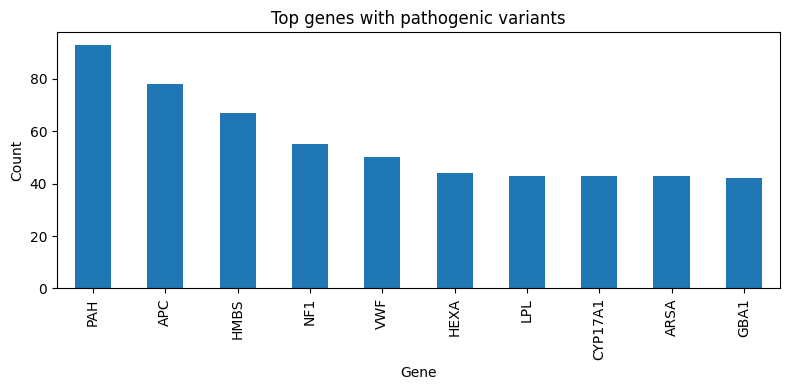

In [6]:
ax = gene_counts.head(10).plot(kind="bar", figsize=(8, 4))

plt.title("Top genes with pathogenic variants")
plt.xlabel("Gene")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../figures/clinvar_top_genes.png", dpi=150)
plt.show()

## Interpretation

Pathogenic variants are not evenly distributed across genes. Some genes appear more frequently, reflecting their importance in disease mechanisms.

This simple analysis demonstrates how publicly available clinical variant data can be used to identify biologically relevant genes for further study.